# Islamabad Housing Price Prediction
### Predicting residential property prices using real estate data from Zameen.com

**Tools:** Python · NumPy · Pandas · Matplotlib  
**Model:** Linear Regression via Gradient Descent  
**Dataset:** 1,005 property listings scraped from Zameen.com, Islamabad


This project builds a housing price prediction model without using any
machine learning libraries for the core algorithm. Gradient descent is
implemented from scratch to understand the mechanics of model training.

## 1. Setup

Standard scientific Python stack. No ML libraries are used for the model
itself — NumPy handles all matrix operations manually.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Raw Data

The CSV was exported from a browser scraper, so column names are
auto-generated hash strings rather than readable labels. We load the
raw file first to inspect its structure before selecting and renaming
the relevant features.

In [4]:
df= pd.read_csv('data.csv')


## 3. Feature Selection

The raw export contains 26 columns — mostly scraper metadata (listing
URLs, image sources, internal IDs). Only 5 columns contain the
information needed for price prediction:

| Raw column name | Meaning |
|---|---|
| `dc381b54` | Listing price (string, e.g. "9.95 Crore") |
| `db1aca2f` | Property location (string) |
| `_6d9b9b83` | Number of bedrooms |
| `_6d9b9b83 (2)` | Number of bathrooms |
| `cb0c0514` | Area (string, e.g. "1 Kanal", "5 Marla") |

We select only these columns and rename them immediately.

In [5]:
keep_cols = [
    'dc381b54',     # Price
    'db1aca2f',     # Location
    '_6d9b9b83',    # Bedrooms
    '_6d9b9b83 (2)',# Bathrooms
    'cb0c0514',     # Area
]
df = df[keep_cols]
df.head()

,dc381b54,db1aca2f,_6d9b9b83,_6d9b9b83 (2),cb0c0514
0,9.95 Crore,"DHA Defence Phase 2, DHA Defence",7.0,6.0,1 Kanal
1,12.9 Crore,"DHA Defence Phase 2, DHA Defence",6.0,6.0,1 Kanal
2,8.8 Crore,"DHA Defence Phase 2, DHA Defence",6.0,6.0,1 Kanal
3,11.5 Crore,"DHA Defence Phase 2, DHA Defence",5.0,6.0,1 Kanal
4,11.65 Crore,"DHA Defence Phase 2, DHA Defence",6.0,6.0,1 Kanal


In [6]:
df = df.rename(columns={
    'dc381b54': 'Price',
    'db1aca2f': 'Location',
    '_6d9b9b83': 'Bedrooms',
    '_6d9b9b83 (2)': 'Bathrooms',
    'cb0c0514': 'Area'
})
df.head(3)

,Price,Location,Bedrooms,Bathrooms,Area
0,9.95 Crore,"DHA Defence Phase 2, DHA Defence",7.0,6.0,1 Kanal
1,12.9 Crore,"DHA Defence Phase 2, DHA Defence",6.0,6.0,1 Kanal
2,8.8 Crore,"DHA Defence Phase 2, DHA Defence",6.0,6.0,1 Kanal


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Price      1005 non-null   object 
 1   Location   1005 non-null   object 
 2   Bedrooms   970 non-null    float64
 3   Bathrooms  921 non-null    float64
 4   Area       1005 non-null   object 
dtypes: float64(2), object(3)
memory usage: 39.4+ KB


## 4. Data Type Standardisation

Bedroom and bathroom counts came through as floats because the scraper
sometimes produced null values in those columns. Python's standard
`int64` dtype cannot hold NaN values, so we cast to `Int64` (capital I),
which is a nullable integer type introduced in Pandas 1.0. This preserves
missing values without converting everything to floats.

In [8]:
df['Bedrooms'] = df['Bedrooms'].astype('Int64')
df['Bathrooms'] = df['Bathrooms'].astype('Int64')
#converted to Int64 because that does not throw an error due to null values in columns whereas int64 does throw an error

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1005 non-null   object
 1   Location   1005 non-null   object
 2   Bedrooms   970 non-null    Int64 
 3   Bathrooms  921 non-null    Int64 
 4   Area       1005 non-null   object
dtypes: Int64(2), object(3)
memory usage: 41.3+ KB


## 6. Area Unit Conversion

Pakistani real estate listings use two local area units — Marla and Kanal.
These are not standardised internationally:

- **1 Marla** = 272.251 sq ft  
- **1 Kanal** = 5,445 sq ft (= 20 Marla)

Some listings also use square feet directly. To make area comparable
across all listings, we convert everything to square feet using a custom
parser that detects the unit from the string and applies the appropriate
multiplier. The original `Area` column is dropped after conversion.

In [10]:
def area_to_sqft(area):
    if isinstance(area, str):
        num = float(area.split()[0])
        if 'Marla' in area:
            return num * 272.251
        elif 'Kanal' in area:
            return num * 5445
        elif 'Sq.' in area:
            return num
    return None

df['Area_sqft'] = df['Area'].apply(area_to_sqft)
df.drop(columns=['Area'], inplace=True)

## 7. Price Conversion

Prices on Zameen.com are written as human-readable strings in the South
Asian numbering system:

- **1 Lakh** = 100,000 PKR  
- **1 Crore** = 10,000,000 PKR

The `clean_price()` function strips the unit label, parses the numeric
part, and multiplies by the appropriate factor. After conversion, all
prices are stored as plain floats in PKR, making them directly usable
as the model's target variable.

In [11]:
def clean_price(value):
    if isinstance(value, str):
        value = value.replace(',', '').strip()
        if 'Crore' in value:
            return float(value.replace('Crore', '').strip()) * 10000000
        elif 'Lakh' in value:
            return float(value.replace('Lakh', '').strip()) * 100000
        else:
            try:
                return float(value)
            except:
                return None
    return value
df['Price'] = df['Price'].apply(clean_price)

## 7. Outlier Removal

Real estate datasets commonly contain extreme outliers — unusually large
mansions, data entry errors, or commercial properties mislabelled as
residential. These distort the model's learned coefficients.

We use the **IQR (Interquartile Range)** method:
- Q1 = 25th percentile, Q3 = 75th percentile
- IQR = Q3 − Q1
- Any value below Q1 − 1.5×IQR or above Q3 + 1.5×IQR is removed

This is applied independently to Price, Bedrooms, Bathrooms, and
Area_sqft. The 1.5×IQR threshold is the standard Tukey fence,
which typically retains ~99.3% of normally distributed data while
removing genuine extremes.

In [12]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return cleaned

for col in ['Price', 'Bedrooms', 'Bathrooms', 'Area_sqft']:
    df = remove_outliers(df, col)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 853 entries, 0 to 1003
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Price      853 non-null    float64
 1   Location   853 non-null    object 
 2   Bedrooms   853 non-null    Int64  
 3   Bathrooms  853 non-null    Int64  
 4   Area_sqft  853 non-null    float64
dtypes: Int64(2), float64(2), object(1)
memory usage: 41.7+ KB


In [14]:
df.head()

,Price,Location,Bedrooms,Bathrooms,Area_sqft
0,99500000.0,"DHA Defence Phase 2, DHA Defence",7,6,5445.0
1,129000000.0,"DHA Defence Phase 2, DHA Defence",6,6,5445.0
2,88000000.0,"DHA Defence Phase 2, DHA Defence",6,6,5445.0
3,115000000.0,"DHA Defence Phase 2, DHA Defence",5,6,5445.0
4,116500000.0,"DHA Defence Phase 2, DHA Defence",6,6,5445.0


## 8. Remove Null Values

After outlier removal, any remaining rows with missing values are dropped.
We verify before and after using `isnull().sum()` to confirm no nulls
remain in the training data.

In [15]:
df.isnull().sum()

Price        0
Location     0
Bedrooms     0
Bathrooms    0
Area_sqft    0
dtype: int64

In [16]:
df.dropna(inplace = True)

In [17]:
df.isnull().sum()

Price        0
Location     0
Bedrooms     0
Bathrooms    0
Area_sqft    0
dtype: int64

In [18]:
df.to_csv('cleaned_data.csv', index = False)

In [19]:
cdf = pd.read_csv('cleaned_data.csv')
cdf.head()

,Price,Location,Bedrooms,Bathrooms,Area_sqft
0,99500000.0,"DHA Defence Phase 2, DHA Defence",7,6,5445.0
1,129000000.0,"DHA Defence Phase 2, DHA Defence",6,6,5445.0
2,88000000.0,"DHA Defence Phase 2, DHA Defence",6,6,5445.0
3,115000000.0,"DHA Defence Phase 2, DHA Defence",5,6,5445.0
4,116500000.0,"DHA Defence Phase 2, DHA Defence",6,6,5445.0


##### Prices of houses vary as per the location in Islamabad

## 9. Location Analysis

The raw dataset contains over 230 distinct location strings. Before
deciding how to encode location as a model feature, we first examine
the price distribution across locations to understand which areas have more varying prices. 

By using this location summary csv, we figure out which locations are to be grouped and which are to be kept separated.

In [20]:
location_summary = cdf.groupby('Location')['Price'].agg(
    Count='count',
    Average_Price='mean',
    Median_Price='median',
    Min_Price='min',
    Max_Price='max'
).reset_index()
location_summary.to_csv("location_check.csv", index=False)

## 10. Location Feature Engineering

With 230+ unique location strings, one-hot encoding each one directly
would create 230+ binary columns — most containing only 1–2 listings,
making them statistically meaningless and prone to overfitting.

Instead, we group locations into 8 meaningful parent categories based
on their observed price distributions:

| Category | Rationale |
|---|---|
| `F-5` through `F-12` | F-series sectors show high within-sector variation; kept separate |
| `G-6` through `G-14` | Same reasoning for G-series |
| `DHA` | Consistent pricing across DHA phases |
| `Bahria` | Consistent pricing across Bahria phases |
| `Gulberg`, `Soan Garden`, `PWD`, `Naval Anchorage` | Distinct price tiers |
| `Other` | Remaining locations with insufficient data |

This reduces 230+ columns to 8 binary features while preserving the
location signal that actually matters for pricing.

In [21]:
def refined_location(loc):
    loc = str(loc).lower()
    # Keep individual F- and G- sectors (they vary a lot)
    if any(f"f-{i}" in loc for i in range(5, 13)):
        return loc.upper().split(',')[0]
    elif any(f"g-{i}" in loc for i in range(6, 15)):
        return loc.upper().split(',')[0]
    elif 'dha' in loc:
        return 'DHA'
    elif 'bahria' in loc:
        return 'Bahria'
    elif 'gulberg' in loc:
        return 'Gulberg'
    elif 'soan' in loc:
        return 'Soan_Garden'
    elif 'pwd' in loc:
        return 'PWD'
    elif 'naval' in loc:
        return 'Naval_Anchorage'
    else:
        return 'Other'
#there were 230 different locations in all of the data set but it was not feasible to make 230 different columns, 1 for each distinct location
#but i divided into parent areas looking at if the price ranges of the sub areas were close enough
#while areas in sectors like DHA and Bahria had consistent price trends across their phases, sectors such as F-series and G-series showed higher variation

In [22]:
cdf['Refined_Location'] = cdf['Location'].apply(refined_location)

## 11. One-Hot Encoding

Location is a categorical variable — the model cannot use a string
directly. One-hot encoding creates one binary column per location
category. A property in DHA gets a `1` in the DHA column and `0` in
all others.

`pd.get_dummies()` handles this automatically. The original `Location`
column is dropped after encoding to avoid redundancy.

In [23]:
location_dummies = pd.get_dummies(cdf['Refined_Location'])
cdf = pd.concat([cdf, location_dummies], axis=1)
cdf.drop(columns='Location',inplace= True)

In [24]:
cdf.to_csv('cleaned_data.csv',index = False)
#instead of making another file,converted all that data to the same csv file

In [25]:
cdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 853 entries, 0 to 852
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price                 853 non-null    float64
 1   Bedrooms              853 non-null    int64  
 2   Bathrooms             853 non-null    int64  
 3   Area_sqft             853 non-null    float64
 4   Refined_Location      853 non-null    object 
 5   Bahria                853 non-null    bool   
 6   CAPITAL HEIGHTS       853 non-null    bool   
 7   DHA                   853 non-null    bool   
 8   F-10                  853 non-null    bool   
 9   F-10/1                853 non-null    bool   
 10  F-10/2                853 non-null    bool   
 11  F-10/3                853 non-null    bool   
 12  F-11                  853 non-null    bool   
 13  F-11/1                853 non-null    bool   
 14  F-11/3                853 non-null    bool   
 15  F-11/4                8

## 12. Train/Test Split (80/20)

The dataset is shuffled before splitting to remove any ordering bias
(e.g., if listings were scraped area-by-area, consecutive rows would
share location and likely price). `random_state=42` makes the shuffle
reproducible — running this notebook again produces the exact same split.

80% of rows go to training, 20% to testing. The split index is calculated
arithmetically rather than using a library to keep the process transparent.

In [26]:
cdf = cdf.sample(frac=1, random_state=42).reset_index(drop=True)
#here sample randomly picks rows from data, frac=1 takes 100% of data but in a random order, reset_index(drop=True) resets the indices while dropping the previous ones cuz the data is shuffles so the indices won't be in order either
#random_state makes that rondomization fixed i.e. for every time the code is run we get the same data set
split_index = int(0.8 * len(cdf))

In [27]:
train_df = cdf.iloc[:split_index].copy()
test_df = cdf.iloc[split_index:].copy()
#made copies so as to avoid changes in the original one

In [28]:
train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

In [29]:
print((len(cdf)) == (len(train_df)+len(test_df)))
#same no of rows

True


In [30]:
# Before creating x_train, converting bool to int
for col in train_df.select_dtypes(include=['bool']).columns:
    train_df[col] = train_df[col].astype(int)
    test_df[col] = test_df[col].astype(int)

In [31]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price                 682 non-null    float64
 1   Bedrooms              682 non-null    int64  
 2   Bathrooms             682 non-null    int64  
 3   Area_sqft             682 non-null    float64
 4   Refined_Location      682 non-null    object 
 5   Bahria                682 non-null    int64  
 6   CAPITAL HEIGHTS       682 non-null    int64  
 7   DHA                   682 non-null    int64  
 8   F-10                  682 non-null    int64  
 9   F-10/1                682 non-null    int64  
 10  F-10/2                682 non-null    int64  
 11  F-10/3                682 non-null    int64  
 12  F-11                  682 non-null    int64  
 13  F-11/1                682 non-null    int64  
 14  F-11/3                682 non-null    int64  
 15  F-11/4                6

In [32]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 682 to 852
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price                 171 non-null    float64
 1   Bedrooms              171 non-null    int64  
 2   Bathrooms             171 non-null    int64  
 3   Area_sqft             171 non-null    float64
 4   Refined_Location      171 non-null    object 
 5   Bahria                171 non-null    int64  
 6   CAPITAL HEIGHTS       171 non-null    int64  
 7   DHA                   171 non-null    int64  
 8   F-10                  171 non-null    int64  
 9   F-10/1                171 non-null    int64  
 10  F-10/2                171 non-null    int64  
 11  F-10/3                171 non-null    int64  
 12  F-11                  171 non-null    int64  
 13  F-11/1                171 non-null    int64  
 14  F-11/3                171 non-null    int64  
 15  F-11/4               

In [33]:
x_train = train_df.drop(columns=['Price','Refined_Location']).values
y_train = train_df['Price'].values

## 13. Feature Normalisation (Z-score Standardisation)

Gradient descent is sensitive to feature scale. Bedrooms (range: 2–7)
and Area_sqft (range: ~1,000–15,000) are on completely different scales.
Without normalisation, the gradient for Area would dominate, causing
slow or unstable convergence.

Z-score standardisation transforms each feature to have:
- Mean = 0
- Standard deviation = 1

Formula: `x_normalised = (x − mean) / std`

**Critical implementation detail:** the mean and std are calculated
*only* from the training set, then applied to both train and test sets.
Using test statistics would constitute data leakage i.e. the model would
have implicitly "seen" the test data during training.

In [34]:
x_mean = x_train.mean(axis=0)
x_std  = x_train.std(axis=0)
x_std[x_std == 0] = 1
x_train = (x_train - x_mean) / x_std

In [35]:
x_train.shape

(682, 47)

## 14. Bias Term (Intercept)

A column of ones is appended to the feature matrix. This represents
the model's intercept i.e. the baseline predicted price when all other
features are zero. Without it, the regression line is forced through
the origin, which is almost never appropriate.

After appending, `x_train_bias` has shape `(n_samples, n_features + 1)`.

In [36]:
x_train_bias = np.c_[x_train, np.ones(x_train.shape[0])]
x_train_bias.shape

(682, 48)

## 15. Linear Regression via Gradient Descent (from scratch)

Rather than using scikit-learn's `LinearRegression`, the optimisation
algorithm is implemented manually to understand the mechanics.

**The model:** ŷ = Xw (matrix multiplication of features and coefficients)

**Loss function:** Mean Squared Error (MSE)
`MSE = (1/2N) × Σ(ŷᵢ − yᵢ)²`

**Update rule:** At each iteration, compute the gradient of the loss
with respect to the coefficients, and step in the opposite direction:
`w = w − (α/N) × Xᵀ(Xw − y)`

where:
- `α` = learning rate (controls step size)
- `N` = number of training samples
- `Xᵀ` = transpose of the feature matrix

**Hyperparameters chosen:**
- Learning rate: 0.001 (small enough for stable convergence)
- Iterations: 5,000 (sufficient for this dataset size)
- Initial coefficients: random values seeded at 123 for reproducibility

In [37]:
#initial values
learning_rate = 0.001
iterations = 5000
N = y_train.size
np.random.seed(123)
coeff = np.random.rand(x_train_bias.shape[1])
print("Initial values of coefficients: ",coeff)

Initial values of coefficients:  [0.69646919 0.28613933 0.22685145 0.55131477 0.71946897 0.42310646
 0.9807642  0.68482974 0.4809319  0.39211752 0.34317802 0.72904971
 0.43857224 0.0596779  0.39804426 0.73799541 0.18249173 0.17545176
 0.53155137 0.53182759 0.63440096 0.84943179 0.72445532 0.61102351
 0.72244338 0.32295891 0.36178866 0.22826323 0.29371405 0.63097612
 0.09210494 0.43370117 0.43086276 0.4936851  0.42583029 0.31226122
 0.42635131 0.89338916 0.94416002 0.50183668 0.62395295 0.1156184
 0.31728548 0.41482621 0.86630916 0.25045537 0.48303426 0.98555979]


In [38]:
#Algorithm
def gD(x, y, coeff, iterations, learning_rate):
    past_prices= []
    past_coeff = [coeff]
    for i in range(iterations):
        prediction = np.dot(x_train_bias,coeff)
        error = prediction - y_train
        #Mean square error
        price = 1/(2*N) * np.sum(error**2) #calculating the square through dot product cuz lists
        past_prices.append(price)
        der = (1/N)* learning_rate * np.dot(x_train_bias.T, error)
        coeff =  coeff - der
        past_coeff.append(coeff)
    return past_coeff,past_prices

In [39]:
past_coeff,past_prices  = gD(x_train_bias, y_train, coeff, iterations, learning_rate)
coeff = past_coeff[-1] #last coefficient

In [40]:
print("Final values of coefficients: ", coeff)

Final values of coefficients:  [ 6.38069638e+06  6.11198355e+06  3.02142877e+07 -3.93778050e+06
  4.58557483e+04  6.76763536e+05  7.36444957e+06  1.99198861e+06
  3.78600730e+06  4.48933153e+06  3.09046202e+06  2.87498103e+06
  1.87256283e+06  2.18203162e+06  6.26963548e+06  7.37701586e+06
  1.17022455e+07  2.80888466e+05  1.34741076e+05  1.50035991e+06
  8.04713516e+05  3.11628591e+03  5.76640100e+05  6.11023511e-01
 -7.35414231e+04 -1.90799015e+05 -1.93524266e+04  1.28499765e+06
  1.05693326e+05  1.83699059e+06  4.75803185e+05  7.59397363e+05
  1.82092876e+06 -2.10907021e+05  4.54510081e+05 -4.51935220e+05
  2.59604471e+06  1.90133944e+05  2.51832032e+05 -2.45660196e+06
 -2.29222545e+06 -6.84790264e+06 -4.87577739e+05 -1.11174020e+06
  2.06695274e+06 -4.13216481e+06  4.68691064e+06  6.70456725e+07]


## 16. Training Loss Curve

The MSE recorded at each iteration is plotted to verify convergence.
A correctly tuned gradient descent shows a smooth, monotonically
decreasing curve that flattens as it approaches the minimum.

If the curve oscillates or increases, the learning rate is too high.
If it decreases very slowly, the learning rate is too low.

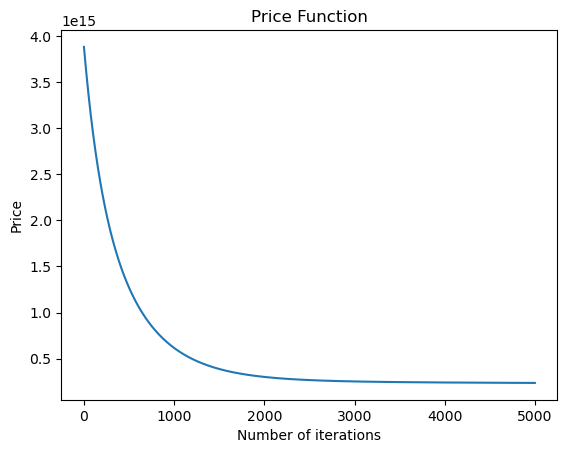

In [41]:
plt.title('Price Function')
plt.xlabel('Number of iterations')
plt.ylabel('Price')
plt.plot(past_prices)
plt.show()

## 17. Generating Predictions on Test Data

The test features are normalised using the *training set* mean and std
(computed in Section 13 — not recomputed from test data). The final
learned coefficients are applied to generate predicted prices.

In [42]:
x_test = test_df.drop(columns=['Price','Refined_Location']).values
y_test = test_df['Price'].values

In [43]:
x_test = (x_test - x_mean) / x_std

In [44]:
x_test_bias = np.c_[x_test, np.ones(x_test.shape[0])]
x_test_bias.shape

(171, 48)

In [45]:
y_pred = np.dot(x_test_bias, coeff)

## 18. Actual vs Predicted Prices

The scatter plot compares actual test prices against predicted prices.
Points along the red diagonal line represent perfect predictions.
Scatter around this line indicates prediction error.

A tight cluster along the diagonal indicates a well-fitted model.
Systematic deviation (e.g., all points above the line for high prices)
indicates the model is underestimating in that range.

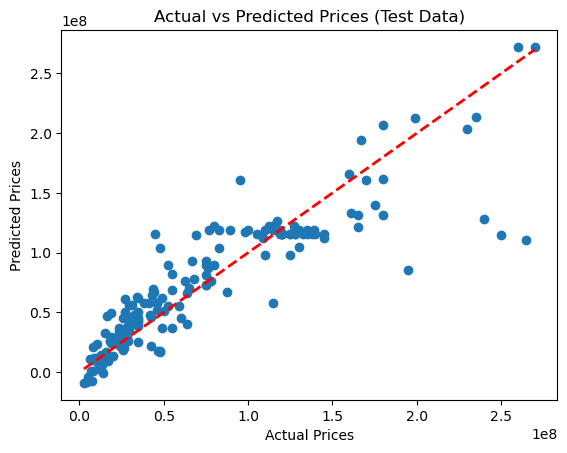

In [46]:
# Plot actual vs predicted prices
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices (Test Data)')
plt.show()

## 19. Root Mean Squared Error (RMSE)

RMSE measures the average magnitude of prediction error in the same
units as the target variable (PKR).

Formula: `RMSE = √(1/2N × Σ(yᵢ − ŷᵢ)²)`

Since prices are in PKR (order of millions to hundreds of millions),
RMSE should be interpreted relative to the price range of the dataset,
not as an absolute number.

In [47]:
test_error = y_test - y_pred
n = y_test.size

In [48]:
price_rmse = (1/(2*n) *np.sum(test_error**2))**0.5
print(price_rmse)

19694939.96543199


## 20. R² Score (Coefficient of Determination)

R² measures what proportion of the variance in house prices the model
explains.

- **R² = 1.0** → perfect fit
- **R² = 0.0** → model performs no better than predicting the mean price
- **R² < 0** → model is worse than a naive mean prediction

Formula: `R² = 1 − (SS_residual / SS_total)`

In [49]:
ss_r = np.sum((y_test - y_pred)**2)  # Sum of squared residuals
ss_t = np.sum((y_test - np.mean(y_test))**2)  # Total sum of squares
r2 = 1 - (ss_r / ss_t)
print(r2)

0.7940323895150403


## 21. Error Distribution

The histogram of residuals (actual − predicted) reveals the pattern
of prediction errors. An ideal model produces residuals that are:
- Centred at zero (no systematic bias)
- Approximately normally distributed (random, not patterned)

Skew in this distribution suggests the model is systematically
over- or under-predicting for a portion of listings.

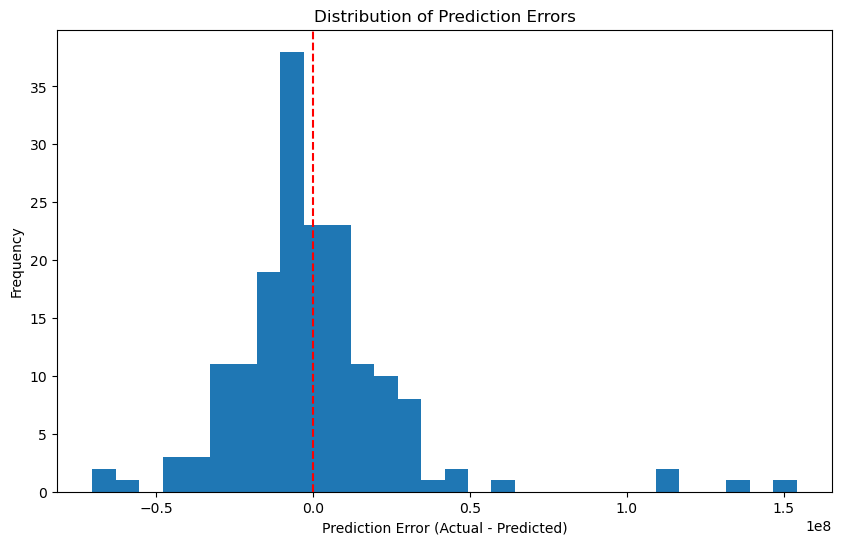

In [50]:
plt.figure(figsize=(10, 6))
plt.hist(test_error, bins=30)
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.axvline(x=0, color='r', linestyle='--')
plt.show()

## 22. Results and Reflection

| Metric | Value |
|---|---|
| Training samples | ~804 |
| Test samples | ~201 |
| Features | Bedrooms, Bathrooms, Area (sqft), Location (one-hot) |
| Algorithm | Gradient Descent (from scratch) |
| R² Score | 0.7940323895150403 |
| RMSE | 19694939.96543199 |
